In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df_quota_raw = pd.read_csv("Hlutdeildir.csv")

In [4]:
df_quota_raw.head()

,Unnamed: 0,Fiskveiðiár,Skr.nr.,Heiti,Útgerðarflokkur,Kvótategund,Hlutdeildir úr gildi,Hlutdeild í upphafi,Hlutdeild í lok,Hlutdeildarbreyting,Útgerð
0,0,2020/2021,1909.0,Gísli ÍS22,Krókaaflamarksbátur,Makríll,31.08.2021,0.000004,0.000004,0.0,1909 ehf.
1,1,2021/2022,1909.0,Gísli ÍS22,Krókaaflamarksbátur,Makríll,31.08.2022,0.000004,0.000004,0.0,1909 ehf.
2,2,2022/2023,1909.0,Gísli ÍS22,Krókaaflamarksbátur,Makríll,31.08.2023,0.000004,0.000004,0.0,1909 ehf.
3,3,2023/2024,1909.0,Gísli ÍS22,Krókaaflamarksbátur,Makríll,31.08.2024,0.000004,0.000004,0.0,1909 ehf.
4,4,2024/2025,1909.0,Gísli ÍS22,Núllflokkur,Makríll,31.08.2025,0.000004,0.000004,0.0,1909 ehf.


In [5]:
df_quota_raw.columns

Index(['Unnamed: 0', 'Fiskveiðiár', 'Skr.nr.', 'Heiti', 'Útgerðarflokkur',
       'Kvótategund', 'Hlutdeildir úr gildi', 'Hlutdeild í upphafi',
       'Hlutdeild í lok', 'Hlutdeildarbreyting', 'Útgerð'],
      dtype='object')

In [6]:
# Clean up
df_quota = df_quota_raw.drop(columns=["Unnamed: 0"]).copy()

species = ['Cod', 'Haddock', 'Herring', 'Capelin', 'Mackerel']

# Translate columns
df_quota.rename(columns={
    "Fiskveiðiár": "Fishing Year",
    "Skr.nr.": "Reg. No.",
    "Heiti": "Vessel Name",
    "Útgerðarflokkur": "Fleet Category",
    "Kvótategund": "Quota Species",
    "Hlutdeildir úr gildi": "Quota Expiry",
    "Hlutdeild í upphafi": "Share Start",
    "Hlutdeild í lok": "Share End",
    "Hlutdeildarbreyting": "Share Change",
    "Útgerð": "Operator"
}, inplace=True)

# Extract the effective year (later year from "2020/2021" -> 2021)
df_quota["Year"] = df_quota["Fishing Year"].str.split("/").str[1].astype(int)

species_keep = {
    "Þorskur": "Cod",
    "Ýsa": "Haddock",
    "Síld": "Herring",
    "Loðna": "Capelin",
    "Makríll": "Mackerel",
}

df_quota["Species"] = df_quota["Quota Species"].map(species_keep)
df_quota = df_quota.dropna(subset=["Species"])

df_quota["Direction"] = df_quota["Share Change"].apply(
    lambda x: "Gain" if x > 0 else ("Loss" if x < 0 else "No Change")
)

df_quota["Abs Change"] = df_quota["Share Change"].abs()


print(f"Rows: {len(df_quota)}")
print(f"Species: {df_quota['Species'].unique().tolist()}")
df_quota.head()

Rows: 62766
Species: ['Mackerel', 'Cod', 'Haddock', 'Herring', 'Capelin']


,Fishing Year,Reg. No.,Vessel Name,Fleet Category,Quota Species,Quota Expiry,Share Start,Share End,Share Change,Operator,Year,Species,Direction,Abs Change
0,2020/2021,1909.0,Gísli ÍS22,Krókaaflamarksbátur,Makríll,31.08.2021,0.000004,0.000004,0.0,1909 ehf.,2021,Mackerel,No Change,0.0
1,2021/2022,1909.0,Gísli ÍS22,Krókaaflamarksbátur,Makríll,31.08.2022,0.000004,0.000004,0.0,1909 ehf.,2022,Mackerel,No Change,0.0
2,2022/2023,1909.0,Gísli ÍS22,Krókaaflamarksbátur,Makríll,31.08.2023,0.000004,0.000004,0.0,1909 ehf.,2023,Mackerel,No Change,0.0
3,2023/2024,1909.0,Gísli ÍS22,Krókaaflamarksbátur,Makríll,31.08.2024,0.000004,0.000004,0.0,1909 ehf.,2024,Mackerel,No Change,0.0
4,2024/2025,1909.0,Gísli ÍS22,Núllflokkur,Makríll,31.08.2025,0.000004,0.000004,0.0,1909 ehf.,2025,Mackerel,No Change,0.0


In [7]:
# Focus on rows with actual changes
changes = df_quota[df_quota["Share Change"] != 0].copy()

# For each (Year, Species), try to match losses to gains of similar magnitude
def flag_inter_operator(group):
    losses = group[group["Direction"] == "Loss"].copy()
    gains = group[group["Direction"] == "Gain"].copy()
    
    matched = set()
    
    for li, lrow in losses.iterrows():
        for gi, grow in gains.iterrows():
            if gi in matched:
                continue
            # Match if the absolute values are close (within 1% tolerance)
            if lrow["Operator"] != grow["Operator"] and \
               abs(lrow["Abs Change"] - grow["Abs Change"]) / max(lrow["Abs Change"], 1e-12) < 0.01:
                matched.add(li)
                matched.add(gi)
                break
    
    group["Inter-Operator"] = group.index.isin(matched)
    return group

df_quota["Inter-Operator"] = False
changes = changes.groupby(["Year", "Species"], group_keys=False).apply(flag_inter_operator)
df_quota.loc[changes.index, "Inter-Operator"] = changes["Inter-Operator"]

# Check results
print(f"Inter-operator transfers: {df_quota['Inter-Operator'].sum()}")
print(f"Internal/other changes:   {((df_quota['Share Change'] != 0) & ~df_quota['Inter-Operator']).sum()}")

df_quota[df_quota["Inter-Operator"]].nlargest(20, "Abs Change")[
    ["Year", "Species", "Vessel Name", "Operator", "Share Change", "Direction", "Inter-Operator"]
]

Inter-operator transfers: 8098
Internal/other changes:   10461


/var/folders/rs/xp_jvmcs6yxft09g6r_s670m0000gn/T/ipykernel_8820/3965518100.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  changes = changes.groupby(["Year", "Species"], group_keys=False).apply(flag_inter_operator)


,Year,Species,Vessel Name,Operator,Share Change,Direction,Inter-Operator
63306,2007,Herring,Björgvin EA311,Samherji hf.,8.870579,Gain,True
67629,2007,Herring,Börkur NK122,Síldarvinnslan hf.,-8.870579,Loss,True
9851,2022,Capelin,Víkingur AK100,Brim hf.,-5.840000,Loss,True
81596,2022,Capelin,Sólborg RE27,Útgerðarfélag Reykjavíkur hf.,5.840000,Gain,True
69146,2001,Herring,Húnaröst SF550,Skinney-Þinganes hf.,-5.662441,Loss,True
76422,2001,Herring,Ásgrímur Halldórsson SF250,Þingey ehf.,5.662441,Gain,True
9698,2016,Herring,Víkingur AK100,Brim hf.,5.545482,Gain,True
67832,2022,Herring,Beitir NK119,Síldarvinnslan hf.,5.545387,Gain,True
87996,2016,Herring,Sighvatur Bjarnason VE81,Vinnslustöðin hf.,-5.545387,Loss,True
88108,2022,Herring,Kap VE4,Vinnslustöðin hf.,-5.545387,Loss,True


In [8]:
df_quota["Year"].min()

1991

In [9]:
df_quota[(df_quota["Inter-Operator"]) & (df_quota["Direction"] == "Gain")].nlargest(10, "Abs Change")[
    ["Year", "Species", "Operator", "Share Change", "Direction"]
]

,Year,Species,Operator,Share Change,Direction
63306,2007,Herring,Samherji hf.,8.870579,Gain
81596,2022,Capelin,Útgerðarfélag Reykjavíkur hf.,5.840000,Gain
76422,2001,Herring,Þingey ehf.,5.662441,Gain
9698,2016,Herring,Brim hf.,5.545482,Gain
67832,2022,Herring,Síldarvinnslan hf.,5.545387,Gain
23444,2004,Herring,Gjögur hf.,3.577336,Gain
48590,2007,Herring,Langanes hf,3.444148,Gain
67644,2008,Herring,Síldarvinnslan hf.,3.345482,Gain
69263,2005,Herring,Skinney-Þinganes hf.,3.327389,Gain
76432,2004,Herring,Þingey ehf.,3.327289,Gain


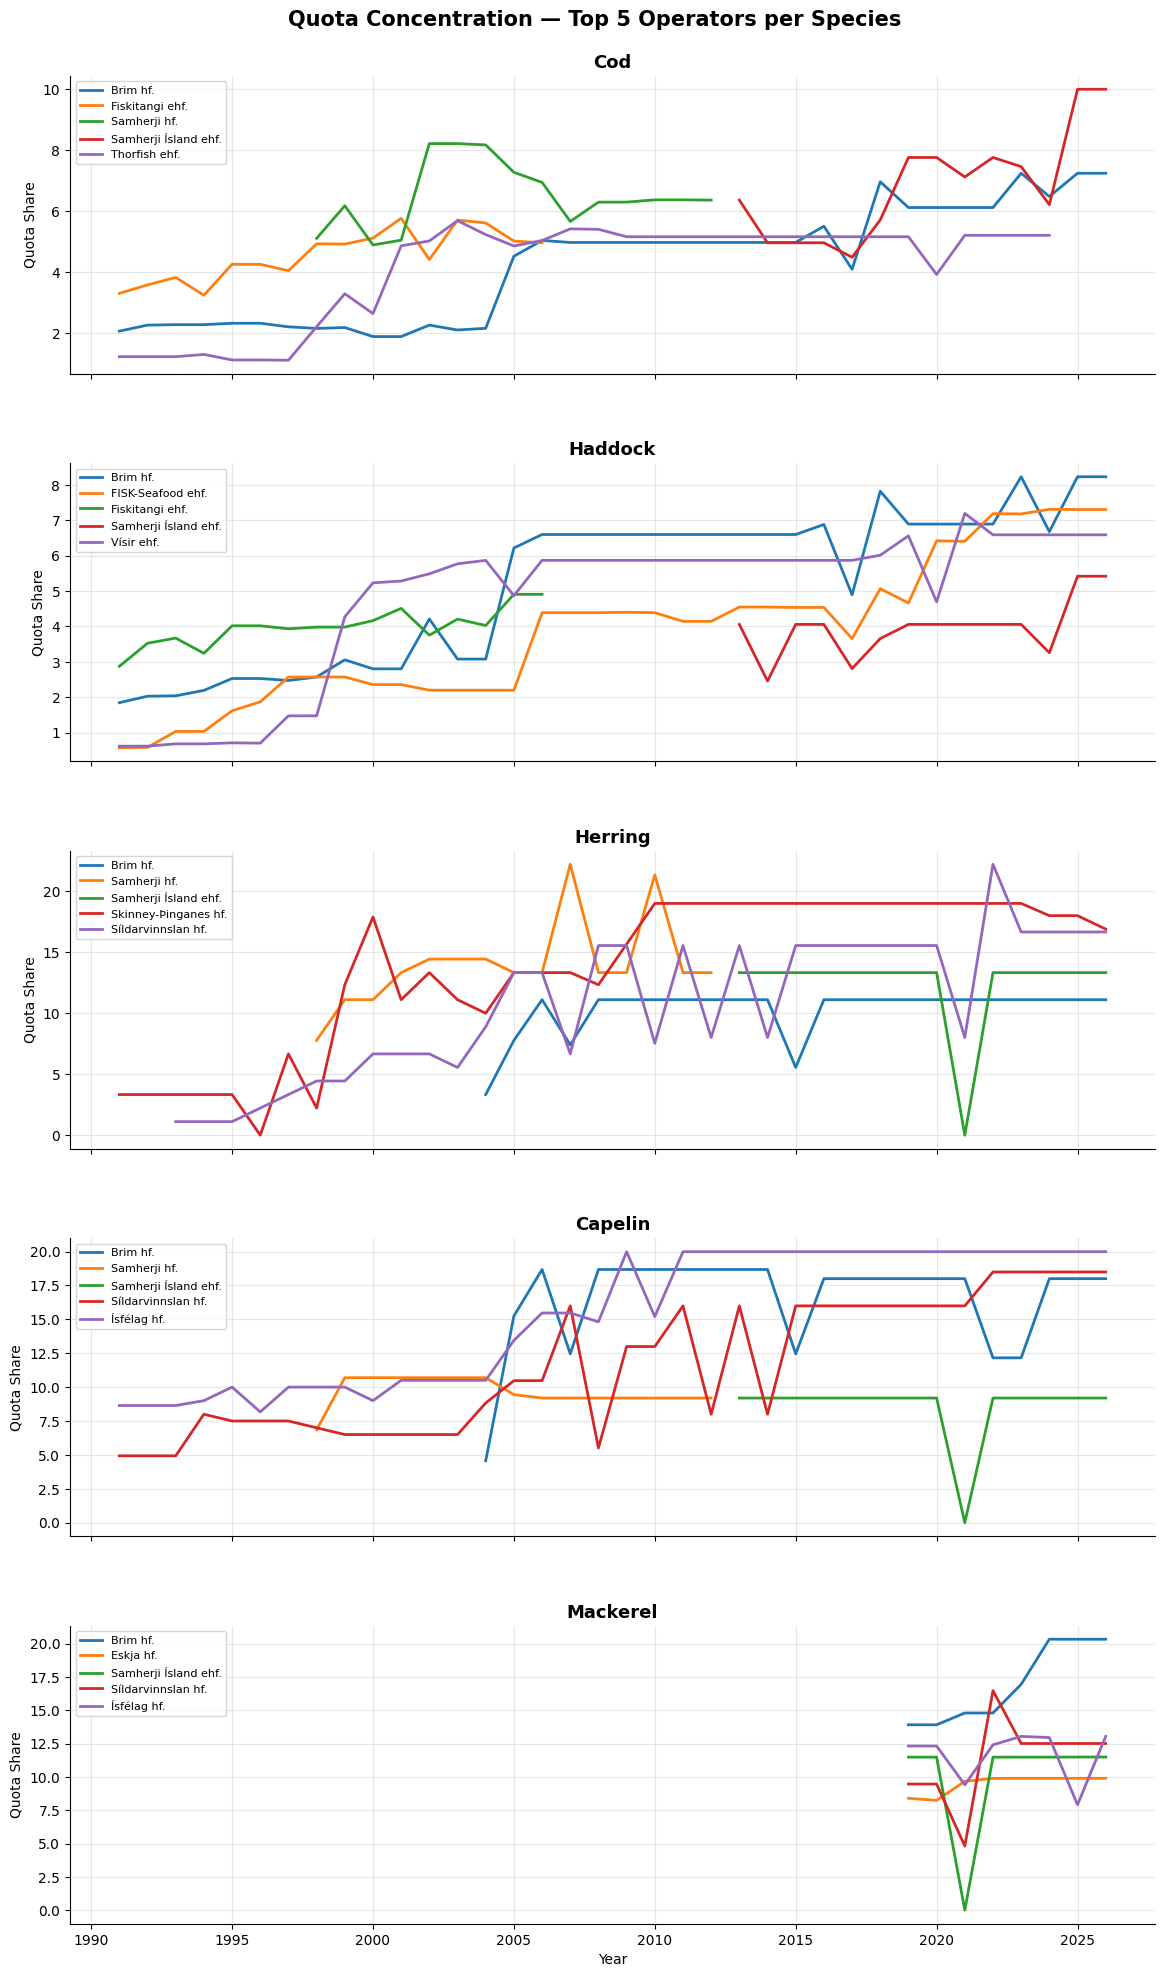

In [10]:
species_list = ["Cod", "Haddock", "Herring", "Capelin", "Mackerel"]

fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=True)

for ax, species in zip(axes, species_list):
    sp = df_quota[df_quota["Species"] == species]
    
    # Aggregate share per operator per year
    op_year = sp.groupby(["Year", "Operator"])["Share End"].sum().reset_index()
    
    # Top 5 operators by mean share for THIS species
    top5_ops = (
        op_year.groupby("Operator")["Share End"]
        .mean()
        .nlargest(5)
        .index
    )
    
    op_year_top = op_year[op_year["Operator"].isin(top5_ops)]
    pivot = op_year_top.pivot(index="Year", columns="Operator", values="Share End")
    
    for col in pivot.columns:
        ax.plot(pivot.index, pivot[col], linewidth=2, label=col)
    
    ax.set_title(species, fontsize=13, fontweight="bold")
    ax.set_ylabel("Quota Share")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Year")
fig.suptitle("Quota Concentration — Top 5 Operators per Species", fontsize=15, fontweight="bold")
fig.subplots_adjust(hspace=0.3, top=0.95)
plt.show()

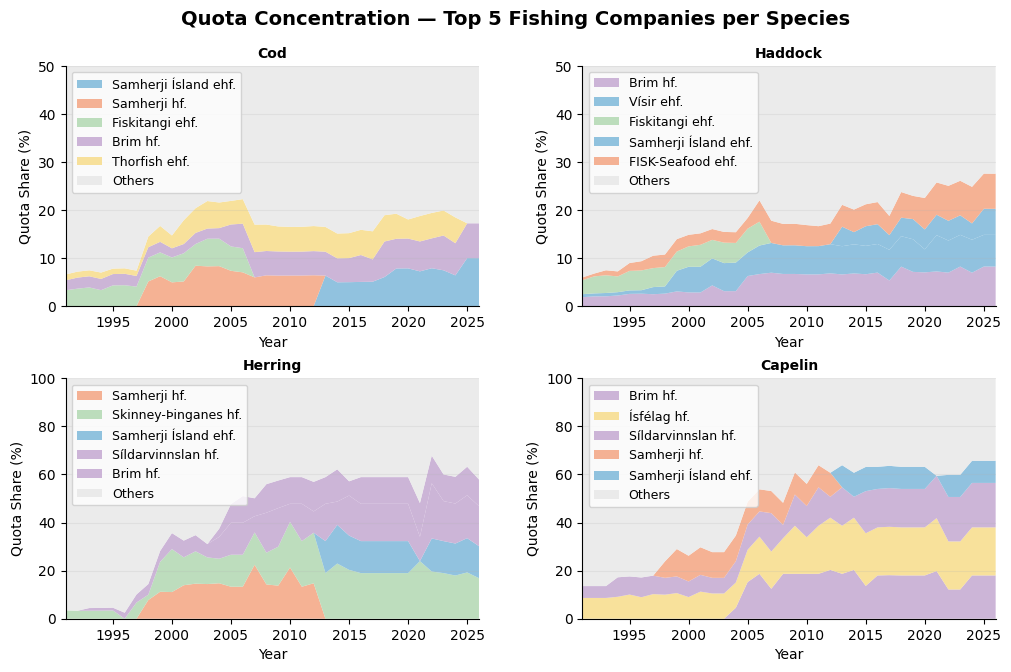

In [11]:
species_list = ["Cod", "Haddock", "Herring", "Capelin"]

soft_colors = ["#7eb8da", "#f4a582", "#b2d8b2", "#c4a8d1", "#f7dc8a"]
others_color = "#e8e8e8"

# Build a global color map: collect all top5 operators across all species
all_top_ops = []
for species in species_list:
    sp = df_quota[df_quota["Species"] == species]
    op_year = sp.groupby(["Year", "Operator"])["Share End"].sum().reset_index()
    top5 = op_year.groupby("Operator")["Share End"].mean().nlargest(5).index.tolist()
    for op in top5:
        if op not in all_top_ops:
            all_top_ops.append(op)

# Extend palette if needed
extended_palette = (soft_colors * ((len(all_top_ops) // len(soft_colors)) + 1))[:len(all_top_ops)]
operator_color_map = {op: extended_palette[i] for i, op in enumerate(all_top_ops)}
operator_color_map["Others"] = others_color

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, species in zip(axes, species_list):
    sp = df_quota[df_quota["Species"] == species]
    
    op_year = sp.groupby(["Year", "Operator"])["Share End"].sum().reset_index()
    
    top5_ops = (
        op_year.groupby("Operator")["Share End"]
        .mean()
        .nlargest(5)
        .index.tolist()
    )
    
    op_year["Group"] = op_year["Operator"].where(op_year["Operator"].isin(top5_ops), "Others")
    grouped = op_year.groupby(["Year", "Group"])["Share End"].sum().reset_index()
    pivot = grouped.pivot(index="Year", columns="Group", values="Share End").fillna(0)
    
    col_order = [c for c in top5_ops if c in pivot.columns] + (["Others"] if "Others" in pivot.columns else [])
    pivot = pivot[col_order]
    
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    
    plot_colors = [operator_color_map[c] for c in pivot_pct.columns]
    
    ax.stackplot(
        pivot_pct.index.values, pivot_pct.values.T,
        labels=pivot_pct.columns.tolist(), colors=plot_colors, alpha=0.85
    )
    
    ax.set_title(species, fontsize=10, fontweight="bold")
    ax.set_ylabel("Quota Share (%)")
    ax.set_xlim(df_quota["Year"].min(), df_quota["Year"].max())
    ax.legend(fontsize=9, loc="upper left", ncol=1)
    ax.grid(True, alpha=0.2, axis="y")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Year")
    
    if species in ["Cod", "Haddock"]:
        ax.set_ylim(0, 50)
    else:
        ax.set_ylim(0, 100)

fig.suptitle("Quota Concentration — Top 5 Fishing Companies per Species", fontsize=14, fontweight="bold")
fig.subplots_adjust(hspace=0.3, wspace=0.25, top=0.90)
plt.show()

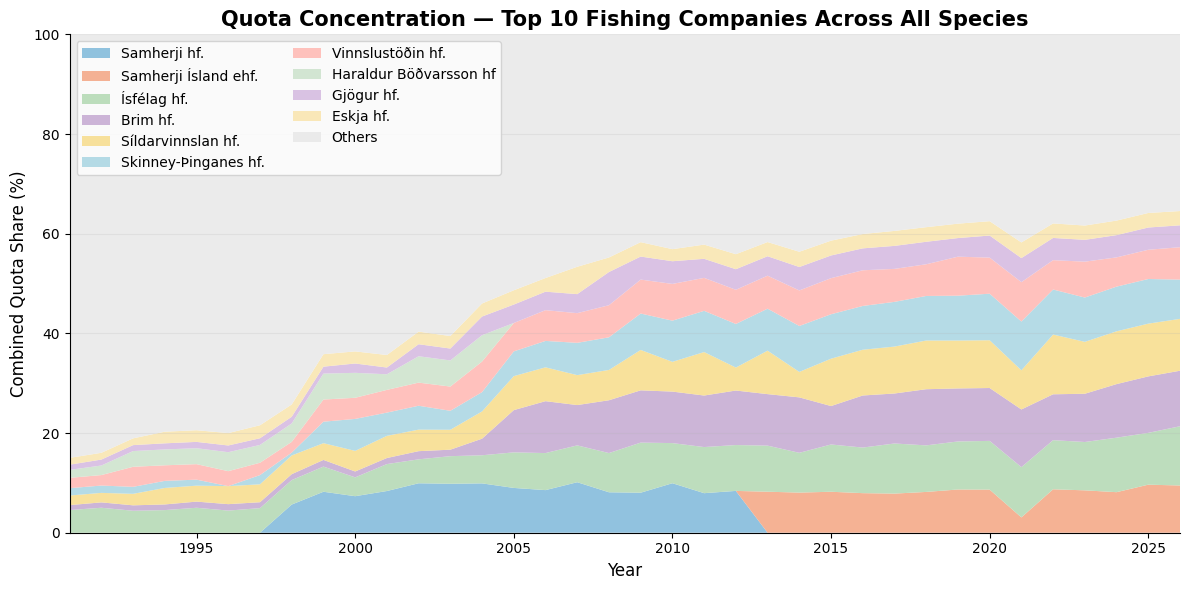

In [12]:
# Aggregate share across all species per operator per year
op_year_all = (
    df_quota[df_quota["Species"].isin(["Cod", "Haddock", "Herring", "Capelin"])]
    .groupby(["Year", "Operator"])["Share End"]
    .sum()
    .reset_index()
)

top10_ops = (
    op_year_all.groupby("Operator")["Share End"]
    .mean()
    .nlargest(10)
    .index.tolist()
)

op_year_all["Group"] = op_year_all["Operator"].where(op_year_all["Operator"].isin(top10_ops), "Others")
grouped = op_year_all.groupby(["Year", "Group"])["Share End"].sum().reset_index()
pivot = grouped.pivot(index="Year", columns="Group", values="Share End").fillna(0)

col_order = [c for c in top10_ops if c in pivot.columns] + (["Others"] if "Others" in pivot.columns else [])
pivot = pivot[col_order]

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

soft_colors = ["#7eb8da", "#f4a582", "#b2d8b2", "#c4a8d1", "#f7dc8a",
               "#a8d5e2", "#ffb7b2", "#cce2cb", "#d4b8e0", "#f9e4ad"]
others_color = "#e8e8e8"

plot_colors = [soft_colors[i] for i, c in enumerate(pivot_pct.columns) if c != "Others"]
if "Others" in pivot_pct.columns:
    plot_colors.append(others_color)

fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(
    pivot_pct.index.values, pivot_pct.values.T,
    labels=pivot_pct.columns.tolist(), colors=plot_colors, alpha=0.85
)

ax.set_title("Quota Concentration — Top 10 Fishing Companies Across All Species", fontsize=15, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Combined Quota Share (%)", fontsize=12)
ax.set_xlim(df_quota["Year"].min(), df_quota["Year"].max())
ax.set_ylim(0, 100)
ax.legend(fontsize=10, loc="upper left", ncol=2)
ax.grid(True, alpha=0.2, axis="y")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
df_quota["From"] = df_quota["Operator"].where(df_quota["Direction"] == "Loss", "")
df_quota["To"] = df_quota["Operator"].where(df_quota["Direction"] == "Gain", "")

In [14]:
df_quota[(df_quota["Inter-Operator"]) & (df_quota["Direction"] == "Gain")].nlargest(10, "Abs Change")[
    ["Year", "Species", "Operator", "Share Change", "Direction", "From", "To"]
]

,Year,Species,Operator,Share Change,Direction,From,To
63306,2007,Herring,Samherji hf.,8.870579,Gain,,Samherji hf.
81596,2022,Capelin,Útgerðarfélag Reykjavíkur hf.,5.840000,Gain,,Útgerðarfélag Reykjavíkur hf.
76422,2001,Herring,Þingey ehf.,5.662441,Gain,,Þingey ehf.
9698,2016,Herring,Brim hf.,5.545482,Gain,,Brim hf.
67832,2022,Herring,Síldarvinnslan hf.,5.545387,Gain,,Síldarvinnslan hf.
23444,2004,Herring,Gjögur hf.,3.577336,Gain,,Gjögur hf.
48590,2007,Herring,Langanes hf,3.444148,Gain,,Langanes hf
67644,2008,Herring,Síldarvinnslan hf.,3.345482,Gain,,Síldarvinnslan hf.
69263,2005,Herring,Skinney-Þinganes hf.,3.327389,Gain,,Skinney-Þinganes hf.
76432,2004,Herring,Þingey ehf.,3.327289,Gain,,Þingey ehf.


In [15]:
# Work with inter-operator transfers only
transfers = df_quota[(df_quota["Inter-Operator"]) & (df_quota["Direction"] == "Gain")].copy()

# For each gain, find the matching loss
def find_source(row, df):
    matches = df[
        (df["Year"] == row["Year"])
        & (df["Species"] == row["Species"])
        & (df["Direction"] == "Loss")
        & (df["Inter-Operator"])
        & ((df["Abs Change"] - row["Abs Change"]).abs() / max(row["Abs Change"], 1e-12) < 0.01)
    ]
    if len(matches) > 0:
        return matches.iloc[0]["Operator"]
    return ""

transfers["From"] = transfers.apply(find_source, axis=1, df=df_quota)
transfers["To"] = transfers["Operator"]

,Year,Species,From,To,Abs Change
63306,2007,Herring,Síldarvinnslan hf.,Samherji hf.,8.870579
81596,2022,Capelin,Brim hf.,Útgerðarfélag Reykjavíkur hf.,5.840000
76422,2001,Herring,Skinney-Þinganes hf.,Þingey ehf.,5.662441
9698,2016,Herring,Vinnslustöðin hf.,Brim hf.,5.545482
67832,2022,Herring,Vinnslustöðin hf.,Síldarvinnslan hf.,5.545387
23444,2004,Herring,Festarfell ehf,Gjögur hf.,3.577336
48590,2007,Herring,Þingey ehf.,Langanes hf,3.444148
67644,2008,Herring,Skinney-Þinganes hf.,Síldarvinnslan hf.,3.345482
69263,2005,Herring,Þingey ehf.,Skinney-Þinganes hf.,3.327389
76432,2004,Herring,Síldarvinnslan hf.,Þingey ehf.,3.327289


In [16]:
transfers[["Year", "Species", "From", "To", "Abs Change"]].nlargest(10, "Abs Change")

,Year,Species,From,To,Abs Change
63306,2007,Herring,Síldarvinnslan hf.,Samherji hf.,8.870579
81596,2022,Capelin,Brim hf.,Útgerðarfélag Reykjavíkur hf.,5.840000
76422,2001,Herring,Skinney-Þinganes hf.,Þingey ehf.,5.662441
9698,2016,Herring,Vinnslustöðin hf.,Brim hf.,5.545482
67832,2022,Herring,Vinnslustöðin hf.,Síldarvinnslan hf.,5.545387
23444,2004,Herring,Festarfell ehf,Gjögur hf.,3.577336
48590,2007,Herring,Þingey ehf.,Langanes hf,3.444148
67644,2008,Herring,Skinney-Þinganes hf.,Síldarvinnslan hf.,3.345482
69263,2005,Herring,Þingey ehf.,Skinney-Þinganes hf.,3.327389
76432,2004,Herring,Síldarvinnslan hf.,Þingey ehf.,3.327289


In [19]:
operator_location = {
    "Síldarvinnslan hf.": "Neskaupstaður",
    "Samherji hf.": "Akureyri",
    "Brim hf.": "Reykjavík",
    "Útgerðarfélag Reykjavíkur hf.": "Reykjavík",
    "Skinney-Þinganes hf.": "Höfn",
    "Þingey ehf.": "Húsavík",
    "Vinnslustöðin hf.": "Vopnafjörður",
    "Festarfell ehf": "Reyðarfjörður",
    "Gjögur hf.": "Norðurfjörður",
    "Langanes hf": "Þórshöfn",
}

transfers["From Town"] = transfers["From"].map(operator_location)
transfers["To Town"] = transfers["To"].map(operator_location)

In [20]:
transfers[["Year", "Species", "From", "From Town", "To", "To Town", "Abs Change"]].nlargest(10, "Abs Change")

,Year,Species,From,From Town,To,To Town,Abs Change
63306,2007,Herring,Síldarvinnslan hf.,Neskaupstaður,Samherji hf.,Akureyri,8.870579
81596,2022,Capelin,Brim hf.,Reykjavík,Útgerðarfélag Reykjavíkur hf.,Reykjavík,5.840000
76422,2001,Herring,Skinney-Þinganes hf.,Höfn,Þingey ehf.,Húsavík,5.662441
9698,2016,Herring,Vinnslustöðin hf.,Vopnafjörður,Brim hf.,Reykjavík,5.545482
67832,2022,Herring,Vinnslustöðin hf.,Vopnafjörður,Síldarvinnslan hf.,Neskaupstaður,5.545387
23444,2004,Herring,Festarfell ehf,Reyðarfjörður,Gjögur hf.,Norðurfjörður,3.577336
48590,2007,Herring,Þingey ehf.,Húsavík,Langanes hf,Þórshöfn,3.444148
67644,2008,Herring,Skinney-Þinganes hf.,Höfn,Síldarvinnslan hf.,Neskaupstaður,3.345482
69263,2005,Herring,Þingey ehf.,Húsavík,Skinney-Þinganes hf.,Höfn,3.327389
76432,2004,Herring,Síldarvinnslan hf.,Neskaupstaður,Þingey ehf.,Húsavík,3.327289


In [23]:
transfers[transfers["Year"] == 1991][["Year", "Species", "From", "From Town", "To", "To Town", "Abs Change"]].nlargest(20, "Abs Change")

,Year,Species,From,From Town,To,To Town,Abs Change
22384,1991,Herring,ENDURNÝJUNARRÉTTUR FELDUR NIÐUR,NaN,Geir ehf.,NaN,1.109095
51871,1991,Herring,ENDURNÝJUNARRÉTTUR FELDUR NIÐUR,NaN,Miðnes hf,NaN,1.109095
56815,1991,Herring,ENDURNÝJUNARRÉTTUR FELDUR NIÐUR,NaN,Ós ehf.,NaN,1.109095
76351,1991,Herring,ENDURNÝJUNARRÉTTUR FELDUR NIÐUR,NaN,Þinganes ehf,NaN,1.109095
51881,1991,Haddock,ENDURNÝJUNARRÉTTUR FELDUR NIÐUR,NaN,Miðnes hf,NaN,0.539192
85452,1991,Haddock,ENDURNÝJUNARRÉTTUR FELDUR NIÐUR,NaN,Valbjörn ehf,NaN,0.335458
85451,1991,Cod,ENDURNÝJUNARRÉTTUR FELDUR NIÐUR,NaN,Valbjörn ehf,NaN,0.315192
74971,1991,Haddock,ENDURNÝJUNARRÉTTUR FELDUR NIÐUR,NaN,Svavar Ágústsson,NaN,0.235348
64580,1991,Haddock,ENDURNÝJUNARRÉTTUR FELDUR NIÐUR,NaN,Siglfirðingur hf.,NaN,0.140609
51832,1991,Cod,Hólanes hf,NaN,Miðfell hf,NaN,0.137037
